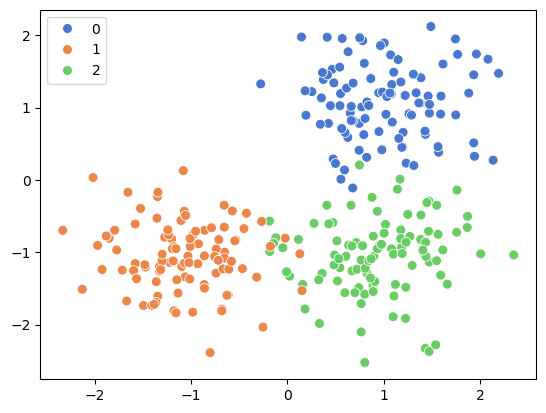

In [141]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
centers = [[1, 1], [-1, -1], [1, -1]]
X, y = make_blobs(n_samples=300, centers=centers, cluster_std=0.5, random_state=0)
sns.scatterplot(x=X[:, 0], y=X[:, 1],hue=y, palette='muted', s=50);

In [142]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
X_SS = StandardScaler().fit_transform(X)
X_MM = MinMaxScaler().fit_transform(X)

similarities = -np.linalg.norm(X_MM[:, np.newaxis] - X_MM[np.newaxis, :], axis=2)
preference = np.median(similarities)

In [151]:
from sklearn.cluster import AffinityPropagation
AP = AffinityPropagation(random_state=0,
                        preference=-100,
                        damping=0.9,
                        convergence_iter=15,
                        )
AP.fit(X_SS)

AffinityPropagation(damping=0.9, preference=-100, random_state=0)

In [152]:
labels = AP.labels_
cluster_centers_indices = AP.cluster_centers_indices_
n_clusters_ = len(AP.cluster_centers_indices_)

n_clusters_

3

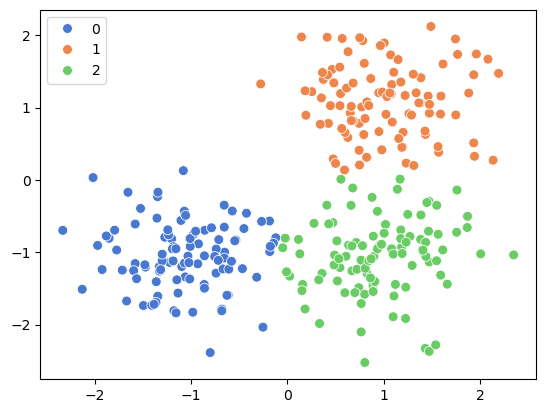

In [153]:
sns.scatterplot(x=X[:, 0], y=X[:, 1],hue=labels, palette='muted', s=50);

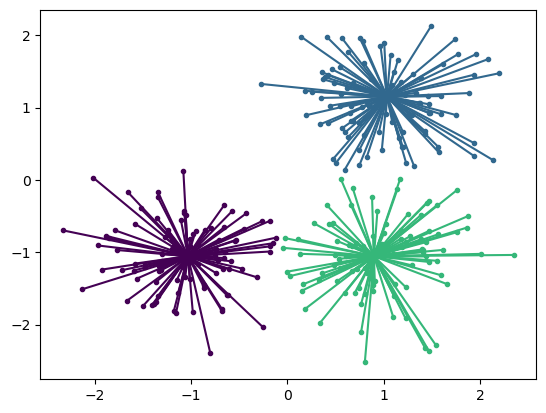

In [154]:
colors = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))
for k, col in zip(range(n_clusters_), colors):
    class_members = labels == k
    cluster_center = X[cluster_centers_indices[k]]
    plt.scatter(
        X[class_members, 0], X[class_members, 1], color=col["color"], marker="."
    )
    plt.scatter(
        cluster_center[0], cluster_center[1], s=14, color=col["color"], marker="o"
    )
    for x in X[class_members]:
        plt.plot(
            [cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"]
        )
